In [1]:
import pandas as pd
import pickle
import torch
import numpy as np
from tqdm import tqdm
from sklearn.neighbors import KernelDensity as KDE

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

plt.rcParams["font.family"] = "Times New Roman"

/Users/kotzen/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
inf = pd.read_csv('../results/infectivity/2024-02-05/mutation_effects.csv')
neup = pd.read_csv('../results/neutralization/2024-01-19/mutation_effects_within_pools.csv')
neu = pd.read_csv('../results/neutralization/2024-01-19/mutation_effects_across_pools.csv')

In [3]:
with open('../model_infectivity/2024-02-05/mcmc_chain.pkl', 'rb') as p:
    inf_samples = pickle.load(p)
inf_data = torch.load('../model_infectivity/2024-02-05/mcmc_input_data.pt')
with open('../model_neutralization/2024-01-19/mcmc_chain.pkl', 'rb') as p:
    neu_samples = pickle.load(p)
neu_data = torch.load('../model_neutralization/2024-01-19/mcmc_input_data.pt')

In [4]:
print(inf_samples['σ_m'].mean())
print(f"Total number of infectivity mutations: {len(inf['Mutation'].unique())}")
inf[inf['Effect'].apply(lambda x: abs(x)) > inf_samples['σ_m'].mean().item()].sort_values(by='Effect', ascending=False)

tensor(0.4980)
Total number of infectivity mutations: 141


,Mutation,Effect,N
0,S704L,1.156543,48.0
1,E484V,0.972844,30.0
2,V83A,0.947476,72.0
3,N501Y,0.745599,360.0
4,K356T,0.703990,24.0
5,P681H,0.639126,330.0
134,N439R,-0.556460,24.0
135,P681R,-0.564872,27.0
136,H655Y,-0.702046,354.0
137,S155R,-0.711008,55.0


In [5]:
temp = inf[inf['Mutation'].apply(lambda x: 'del' in x and x!='Y144del')]
print('Mean effect magnitude:', ((temp['Effect']**2)**0.5).mean())
print(', '.join([mut for mut in temp.Mutation]))

Mean effect magnitude: 0.16089702045751939
H69del, V70del, P26del, Y145del, P25del, V143del, L24del, V483del, N211del


NTD (13-304):
V83A (0.947)
S155R (-0.711)
Y144del (-1.549)

RBD (319-541):
E484V
N501Y
K356T
N439R
R403T

S1/S2 cleavage region (672-709):
S704L
P681H
P681R
A701V

None:
H655Y

In [6]:
inf_samples

{'b': tensor([ 0.0349, -0.0175, -0.0337,  ...,  0.0110,  0.0019,  0.0008]),
 'm': tensor([[-0.7014, -0.4513, -0.1761,  ..., -0.5271,  0.2998,  1.2852],
         [ 0.6282, -0.1980, -0.0797,  ...,  0.1469, -0.2352, -1.0160],
         [-0.3634, -0.2521, -0.1840,  ..., -0.6458,  0.1718,  1.2086],
         ...,
         [ 0.0775, -0.4108, -0.2134,  ..., -0.4245, -0.4740,  0.5516],
         [ 0.1502, -0.1164, -0.0127,  ...,  0.1101,  0.4804, -0.2702],
         [ 0.6943, -0.3786, -0.2091,  ..., -0.5803, -0.0125,  0.4615]]),
 'σ': tensor([0.1721, 0.1945, 0.1739,  ..., 0.1836, 0.1777, 0.1795]),
 'σ_b': tensor([9.4852e-02, 1.8326e+00, 2.3790e-01,  ..., 1.8297e-02, 2.4979e-01,
         8.8882e-04]),
 'σ_m': tensor([0.5416, 0.5341, 0.5316,  ..., 0.4671, 0.4467, 0.5550])}

In [7]:
muts = pd.DataFrame({'Mutation':inf_data['features'],
                     'Mean':inf_samples['m'].mean(dim=0),
                     'Std':inf_samples['m'].std(dim=0)})
muts['Factor'] = muts['Mean'] / muts['Std']
muts.sort_values(by='Factor', ascending=False)

,Mutation,Mean,Std,Factor
108,S704L,1.156543,0.145194,7.965486
12,E484V,0.972844,0.172950,5.625009
52,L452R,0.306965,0.060302,5.090480
90,R346T,0.178905,0.036956,4.841034
95,R683N,0.454697,0.100216,4.537169
...,...,...,...,...
61,N439R,-0.556460,0.097043,-5.734168
92,R403T,-1.349374,0.158824,-8.496035
98,S155R,-0.711008,0.079242,-8.972565
5,A701V,-1.043267,0.111194,-9.382439


In [8]:
muts = pd.DataFrame({'Mutation':inf_data['features'],
                     '5%':torch.quantile(inf_samples['m'], torch.tensor(0.05), dim=0),
                     '50%':torch.quantile(inf_samples['m'], torch.tensor(0.5), dim=0),
                     '95%':torch.quantile(inf_samples['m'], torch.tensor(0.95), dim=0)})
muts.sort_values(by='5%', ascending=False)

,Mutation,5%,50%,95%
108,S704L,0.912747,1.160611,1.382879
12,E484V,0.687624,0.972865,1.260648
128,V83A,0.342590,0.941773,1.557509
95,R683N,0.294396,0.454679,0.619618
41,K356T,0.291901,0.695086,1.128508
...,...,...,...,...
84,Q498Y,-1.071705,-0.494871,0.106452
78,P681R,-1.080772,-0.570082,-0.062487
5,A701V,-1.231238,-1.044525,-0.864205
92,R403T,-1.612063,-1.349155,-1.075494


In [9]:
sum(inf_samples['m'][:, inf_data['features'].index('Q498Y')]>0) / inf_samples['m'].shape[0]

tensor(0.0880)

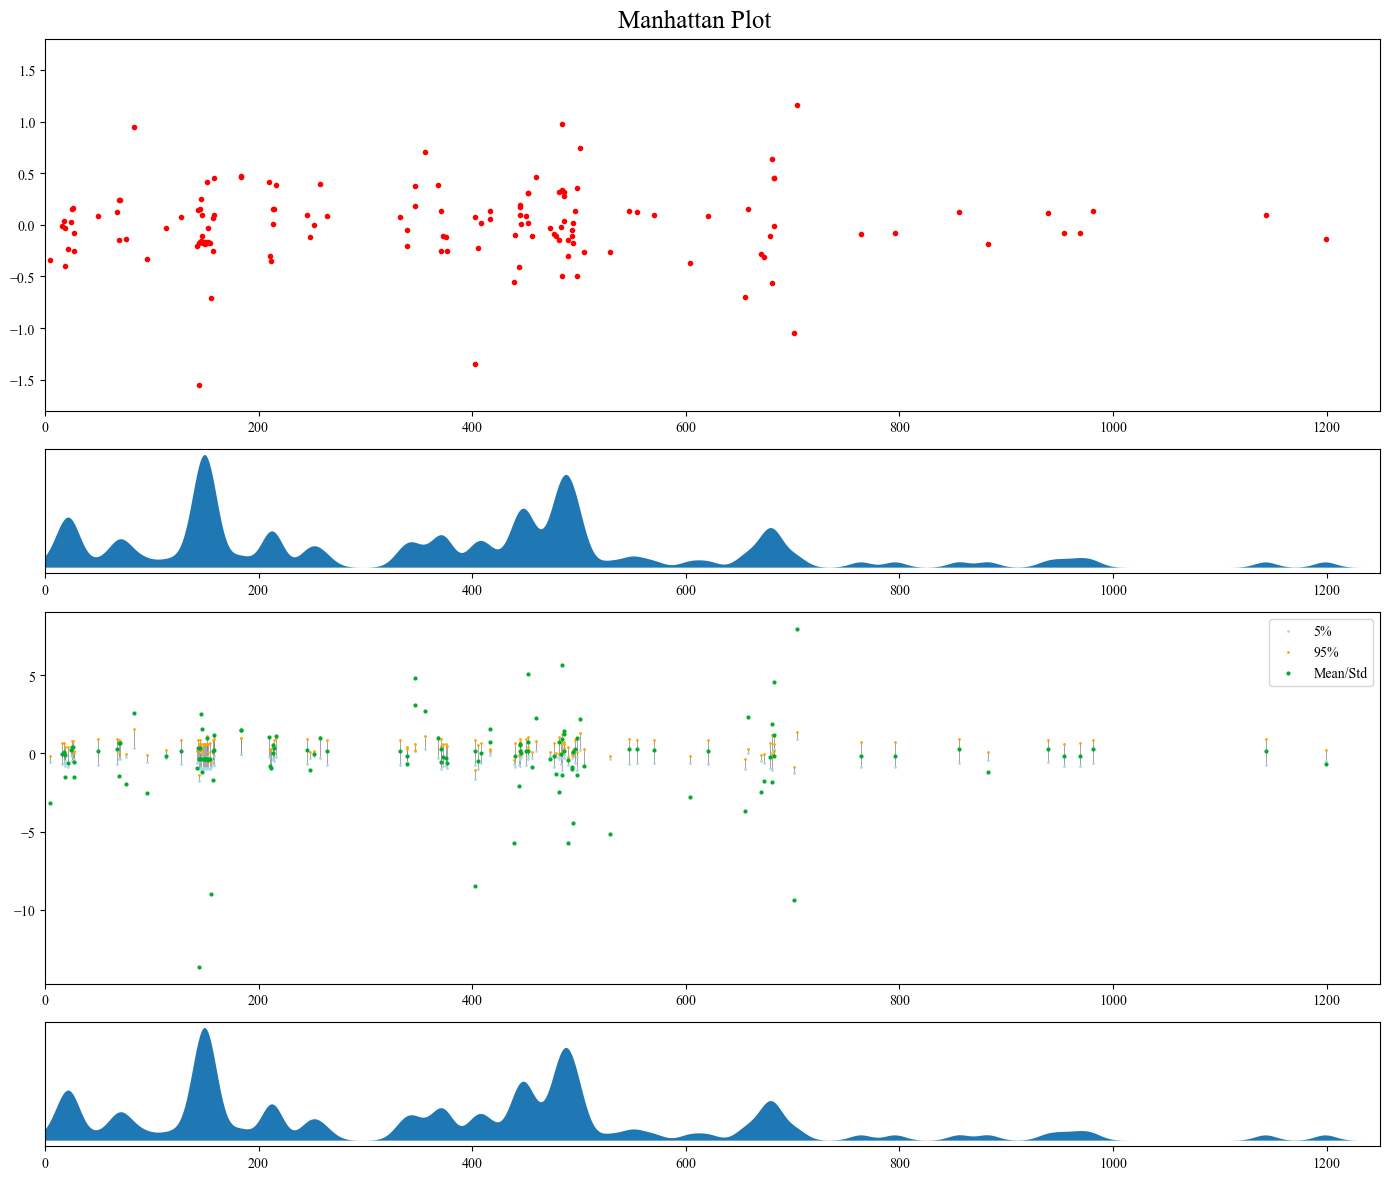

In [10]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(4,1, figsize=(14,12), gridspec_kw={'height_ratios': [4.5, 1.5, 4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1250]
    options['ylim'] = [-1.8, 1.8]#[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    axes[2].set_xlim(options['xlim'])
    # axes[0].set_ylim(options['ylim'])
    
    axes[3].set_xlim(options['xlim'])
    axes[3].set_yticks([])
    
    return fig, axes, options

def preprocess_manhattan(samples, labels):
    means = samples.mean(dim=0)
    coefficients = labels.copy()
    
    positions = [int(''.join(filter(str.isdigit, c))) for c in coefficients] #[int(c[1:-1]) for c in coefficients]
    return means, positions, coefficients

def plot_coef(ax, means, positions, coefficients, options):
    ax.plot(positions, means, 'ro', markersize=3, label='Mean')
    
    # texts = []
    # for i, (pos, fea) in enumerate(zip(positions, coefficients)):
    #     x = pos
    #     y = means[i]
    #     text = fea #+ '\n' + '{:1.2f}'.format(y)
    #     texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_95(ax, samples, positions):
    width=1
    low = []
    high = []
    for i, p in enumerate(positions):
        y1 = torch.quantile(inf_samples['m'], torch.tensor(0.05), dim=0)[i]
        y2 = torch.quantile(inf_samples['m'], torch.tensor(0.95), dim=0)[i]
        ax.vlines([p], y1, y2, color='gray', linewidth=0.5)
        low += [y1]
        high += [y2]
    ax.plot(positions, low, 'o', color='lightblue', markersize=1, alpha=1, label='5%')
    ax.plot(positions, high, 'o', color='orange',    markersize=1, alpha=1, label='95%')
       
        
def plot_metric(ax, samples, positions):
    # ax = ax.twinx()
    metric = samples.mean(dim=0) / samples.std(dim=0)
    ax.plot(positions, metric, 'o', color='xkcd:kelly green', markersize=2, label='Mean/Std')
    
    
def plot_density(ax, positions, options):
    xlim = options['xlim']
    ylim = options['ylim']
    num_points=1000
    # Fit KDE
    kde = KDE(kernel='gaussian', bandwidth=10).fit(np.array(positions).reshape(-1,1))
    x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
    # Generate KDE curve
    y = np.exp(kde.score_samples(x))
    
    ax.fill_between(x.flatten(), np.zeros_like(y), y)
    
    return kde


fig, axes, options = setup()
all_means, positions, coefficients = preprocess_manhattan(inf_samples['m'], inf_data['features'])
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], all_means, positions, coefficients, options)
kde = plot_density(axes[3], positions, options)
plot_95(axes[2], inf_samples['m'], positions)
plot_metric(axes[2], inf_samples['m'], positions)
axes[2].legend()
fig.suptitle('Manhattan Plot', fontsize=18)
fig.tight_layout()
# fig.savefig('figs/infectivity/Results/Manhattan.png', dpi=150)

In [11]:
neu_samples.keys()

dict_keys(['b', 'm0', 'mp', 'σ', 'σ_b', 'σ_m', 'σ_mp'])

In [12]:
print(neu_samples['σ_m'].mean())
print(len(neu['Mutation'].unique()))
neu[neu['Mean Effect'].apply(lambda x: abs(x)) > neu_samples['σ_m'].mean().item()].sort_values(by='Mean Effect')

tensor(0.3297)
110


,Mutation,Mean Effect,N
0,K444T,-0.656364,61.0
1,F486S,-0.625525,367.0
2,L452R,-0.578281,620.0
3,K417N,-0.526447,1295.0
4,F486P,-0.471236,19.0
5,S494R,-0.390986,257.0
6,K147N,-0.339669,339.0
109,S155R,0.437400,189.0


NTD (13-304):
K147N (-0.34) (beta-hairpin, supersite)
S155R ( 0.44) (beta-hairpin, supersite)

RBD (319-541):
K444T (-0.66) (in RBM, Shang)
F486S (-0.63) (in RBM)
L452R (-0.58) (in RBM, Yi)
K417N (-0.53)
F486P (-0.47) (in RBM)
S494R (-0.34) (in RBBM, Shang)

In [13]:
muts = pd.DataFrame({'Mutation':neu_data['features'],
                     'Mean':neu_samples['m0'].mean(dim=0),
                     'Std':neu_samples['m0'].std(dim=0)})
muts['Factor'] = muts['Mean'] / muts['Std']
muts.sort_values(by='Factor', ascending=True)

,Mutation,Mean,Std,Factor
48,L452R,-0.578281,0.108835,-5.313372
85,S494R,-0.390986,0.081171,-4.816803
76,R346T,-0.314283,0.083603,-3.759232
39,K444T,-0.656364,0.203037,-3.232731
19,F486S,-0.625525,0.210458,-2.972208
...,...,...,...,...
86,S704L,0.187463,0.205831,0.910762
27,G339H,0.245320,0.246352,0.995810
93,T478K,0.192458,0.162098,1.187300
38,K417V,0.227401,0.147126,1.545622


In [14]:
muts = pd.DataFrame({'Mutation':neu_data['features'],
                     '5%':torch.quantile(neu_samples['m0'], torch.tensor(0.05), dim=0),
                     '50%':torch.quantile(neu_samples['m0'], torch.tensor(0.5), dim=0),
                     '95%':torch.quantile(neu_samples['m0'], torch.tensor(0.95), dim=0)})
muts.sort_values(by='95%', ascending=True)

,Mutation,5%,50%,95%
48,L452R,-0.758162,-0.576823,-0.400166
39,K444T,-0.996668,-0.652425,-0.340149
19,F486S,-0.962149,-0.622442,-0.291669
85,S494R,-0.533155,-0.388906,-0.256792
36,K417N,-0.838314,-0.522175,-0.216301
...,...,...,...,...
29,G496S,-0.510110,0.004942,0.571091
94,T547K,-0.500128,0.023000,0.574658
107,Y145del,-0.585923,-0.000761,0.591541
79,S155R,0.221067,0.437207,0.641748


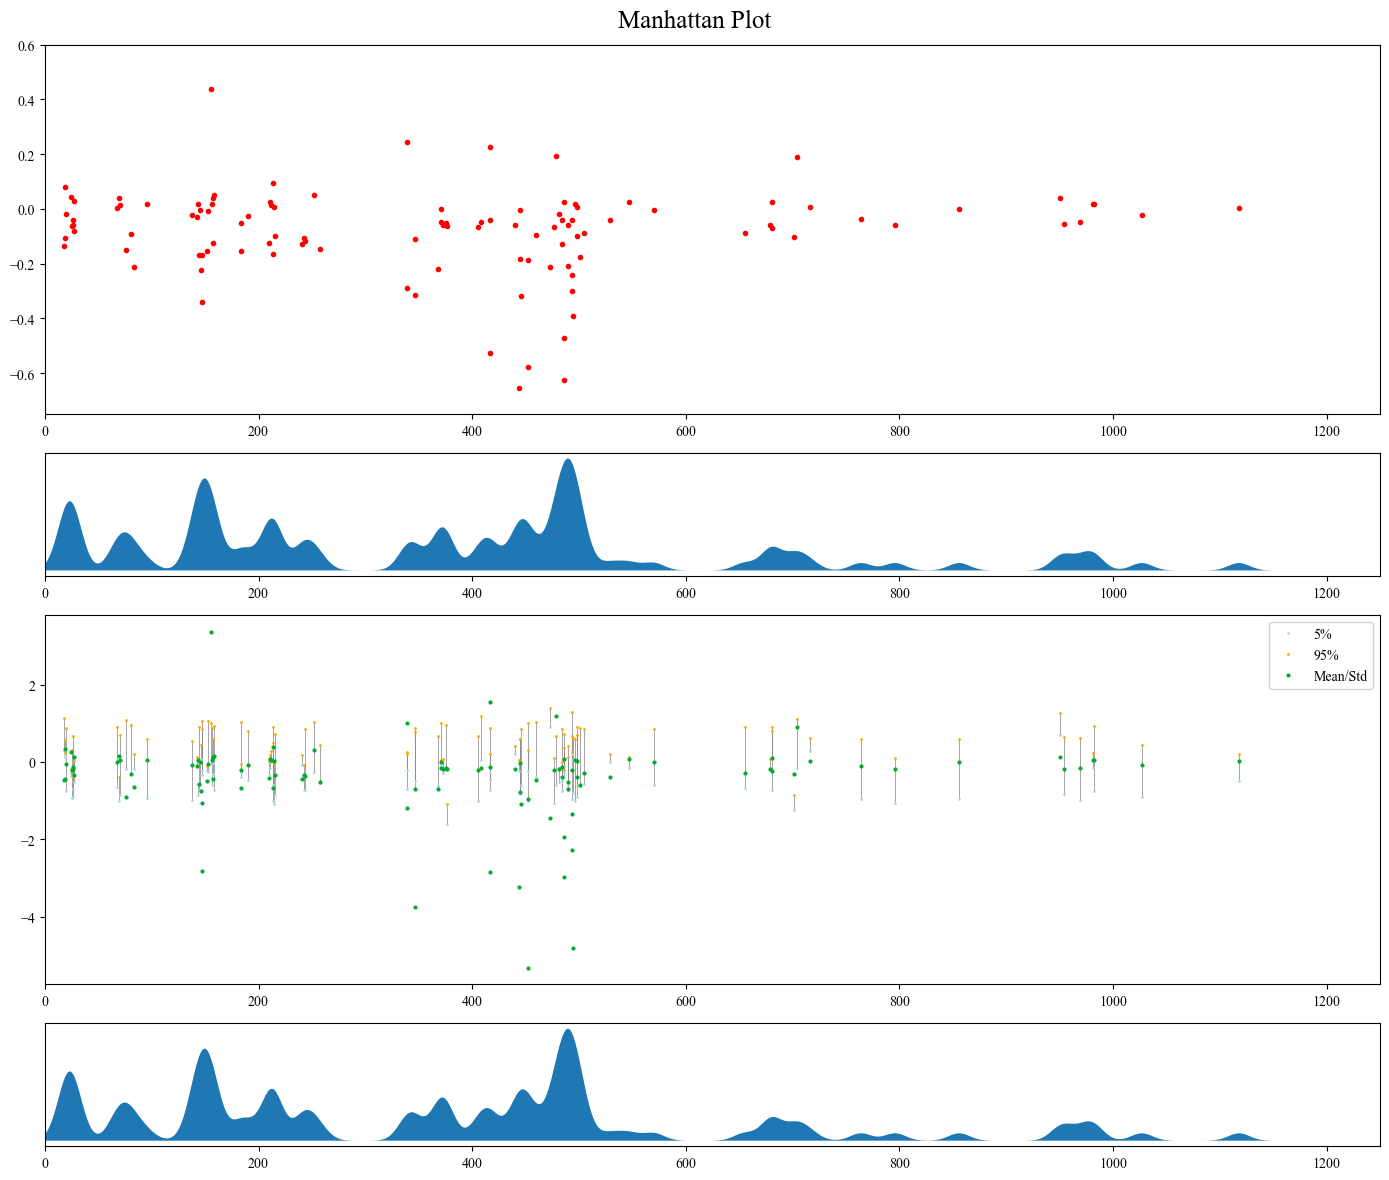

In [15]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(4,1, figsize=(14,12), gridspec_kw={'height_ratios': [4.5, 1.5, 4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1250]
    options['ylim'] = [-0.75, 0.6]#[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    axes[2].set_xlim(options['xlim'])
    # axes[0].set_ylim(options['ylim'])
    
    axes[3].set_xlim(options['xlim'])
    axes[3].set_yticks([])
    
    return fig, axes, options

def preprocess_manhattan(samples, labels):
    means = samples.mean(dim=0)
    coefficients = labels.copy()
    
    positions = [int(''.join(filter(str.isdigit, c))) for c in coefficients] #[int(c[1:-1]) for c in coefficients]
    return means, positions, coefficients

def plot_coef(ax, means, positions, coefficients, options):
    ax.plot(positions, means, 'ro', markersize=3, label='Mean')
    
    # texts = []
    # for i, (pos, fea) in enumerate(zip(positions, coefficients)):
    #     x = pos
    #     y = means[i]
    #     text = fea #+ '\n' + '{:1.2f}'.format(y)
    #     texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_95(ax, samples, positions):
    width=1
    low = []
    high = []
    for i, p in enumerate(positions):
        y1 = torch.quantile(inf_samples['m'], torch.tensor(0.05), dim=0)[i]
        y2 = torch.quantile(inf_samples['m'], torch.tensor(0.95), dim=0)[i]
        ax.vlines([p], y1, y2, color='gray', linewidth=0.5)
        low += [y1]
        high += [y2]
    ax.plot(positions, low, 'o', color='lightblue', markersize=1, alpha=1, label='5%')
    ax.plot(positions, high, 'o', color='orange',    markersize=1, alpha=1, label='95%')
       
        
def plot_metric(ax, samples, positions):
    # ax = ax.twinx()
    metric = samples.mean(dim=0) / samples.std(dim=0)
    ax.plot(positions, metric, 'o', color='xkcd:kelly green', markersize=2, label='Mean/Std')
    
    
def plot_density(ax, positions, options):
    xlim = options['xlim']
    ylim = options['ylim']
    num_points=1000
    # Fit KDE
    kde = KDE(kernel='gaussian', bandwidth=10).fit(np.array(positions).reshape(-1,1))
    x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
    # Generate KDE curve
    y = np.exp(kde.score_samples(x))
    
    ax.fill_between(x.flatten(), np.zeros_like(y), y)
    
    return kde


fig, axes, options = setup()
all_means, positions, coefficients = preprocess_manhattan(neu_samples['m0'], neu_data['features'])
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], all_means, positions, coefficients, options)
kde = plot_density(axes[3], positions, options)
plot_95(axes[2], neu_samples['m0'], positions)
plot_metric(axes[2], neu_samples['m0'], positions)
axes[2].legend()
fig.suptitle('Manhattan Plot', fontsize=18)
fig.tight_layout()
# fig.savefig('figs/infectivity/Results/Manhattan.png', dpi=150)

In [16]:
def _range(series):
 return series.max() - series.min()

ranges = neup[['Mutation', 'Mean Effect']].groupby('Mutation').agg(['min', 'max', _range]).reset_index()
ranges.columns = ranges.columns.droplevel(0)
ranges = ranges.rename(columns={'':'Mutation'})
ranges = ranges.sort_values(by='_range', ascending=False)
ranges

,Mutation,min,max,_range
19,F486S,-0.731451,-0.513006,0.218445
48,L452R,-0.661417,-0.483506,0.177911
46,L368I,-0.300847,-0.127143,0.173704
104,V83A,-0.289370,-0.115956,0.173413
22,F490S,-0.288170,-0.116201,0.171969
...,...,...,...,...
74,R190S,-0.038243,-0.021415,0.016828
91,T20N,-0.028445,-0.012103,0.016342
7,D138Y,-0.032049,-0.017531,0.014518
67,Q493K,-0.047608,-0.034046,0.013562


## KDE Plot

<Axes: xlabel='Position', ylabel='Mean'>

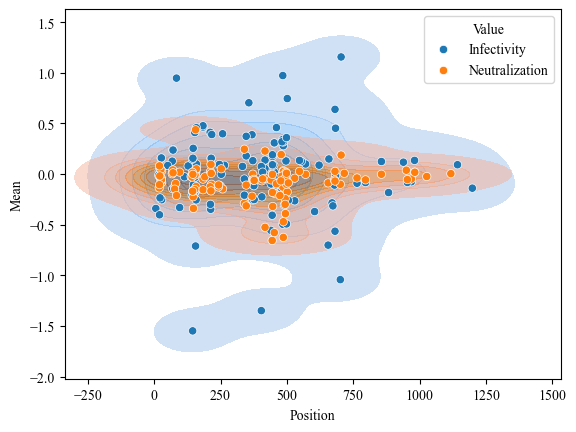

In [17]:
inf_means, inf_positions, inf_coefficients = preprocess_manhattan(inf_samples['m'],  inf_data['features'])
neu_means, neu_positions, neu_coefficients = preprocess_manhattan(neu_samples['m0'], neu_data['features'])
kde_df = pd.concat([
                pd.DataFrame({'Position':inf_positions,
                              'Mean':inf_means,
                              'Value':'Infectivity'}),
                pd.DataFrame({'Position':neu_positions,
                              'Mean':neu_means,
                              'Value':'Neutralization'})])
sns.kdeplot(kde_df, x='Position', y='Mean', hue='Value', thresh=0.01, fill=True, alpha=0.5)
sns.scatterplot(kde_df, x='Position', y='Mean', hue='Value')

### Constructs

In [25]:
inf_seqs = pd.read_csv('../data/Infectivity/CEPI_order_summary - SARS-CoV-2.csv')
print(f"Number of infectivity constructs with designed mutations: {(inf_seqs['# designed mutations'] > 0).sum()}")
print(f"Number of infectivity constructs with no designed mutations: {(inf_seqs['# designed mutations'] == 0).sum()}")
print("Max number of designed mutations: {}".format(inf_seqs['Designed mutations'
                                                    ].apply(lambda x: x.split(',') if x!='--' else []
                                                    ).apply(lambda x: len(x)
                                                    ).max()))
print()

neu_seqs = pd.read_csv('../data/Supp_Material/construct_mutations.csv')
print(f"Number of infectivity constructs with designed mutations: {len(neu_seqs['Designed mutations'].apply(lambda x: None if x=='--' else x).dropna())}")
print(f"Number of infectivity constructs with designed mutations: {len(neu_seqs['Designed mutations'].apply(lambda x: None if x!='--' else x).dropna())}")
print("Max number of designed mutations: {}".format(neu_seqs['Designed mutations'
                                                    ].apply(lambda x: x.split(',') if x!='--' else []
                                                    ).apply(lambda x: len(x)
                                                    ).max()))
print()

inf_seqs = inf_seqs[['new_name', 'Designed mutations', 'All mutations', 'Base VoC']].rename(columns={'new_name':'Name'})
inf_seqs['Infectivity'] = True
neu_seqs = neu_seqs[['Name', 'Designed mutations', 'All mutations', 'base_voc']].rename(columns={'base_voc':'Base VoC'})
neu_seqs['Neutralization'] = True

def create_all_seqs(inf_seqs, neu_seqs, drop=True):
    all_seqs = pd.merge(inf_seqs, neu_seqs, on='Name', how='outer')
    all_seqs['Designed mutations'] = \
        (all_seqs['Designed mutations_x'].apply(lambda x: x.split(',') if (x!='--' and not pd.isna(x)) else []) + \
        all_seqs['Designed mutations_y'].apply(lambda x: x.split(',') if (x!='--' and not pd.isna(x)) else [])).apply(lambda x: list(set(x)))
    all_seqs['All mutations'] = \
        (all_seqs['All mutations_x'].apply(lambda x: x.split(',') if (x!='--' and not pd.isna(x)) else []) + \
        all_seqs['All mutations_y'].apply(lambda x: x.split(',') if (x!='--' and not pd.isna(x)) else [])).apply(lambda x: list(set(x)))
    all_seqs['Base VoC'] = \
        (all_seqs['Base VoC_x'].apply(lambda x: [x] if not pd.isna(x) else []) + \
        all_seqs['Base VoC_y'].apply(lambda x: [x] if not pd.isna(x) else [])).apply(lambda x: sorted(list(set(x)))[0])
    all_seqs['# designed mutations'] = all_seqs['Designed mutations'].apply(lambda x: len(x))
    all_seqs['# all mutations'] = all_seqs['All mutations'].apply(lambda x: len(x))
    all_seqs = all_seqs.sort_values(by='# all mutations').reset_index(drop=True)
    
    if not drop:
        return all_seqs
    
    all_seqs = all_seqs.drop(columns=['Designed mutations_x', 'Designed mutations_y', 'All mutations_x', 'All mutations_y', 'Base VoC_x', 'Base VoC_y'])
    return all_seqs

all_seqs = create_all_seqs(inf_seqs, neu_seqs, drop=False)
print(f"Number of shared sequences: {len(all_seqs[((all_seqs['Infectivity']) & (all_seqs['Neutralization']))])}")
print(f"Number of unshared sequences: {len(all_seqs[~((all_seqs['Infectivity']) & (all_seqs['Neutralization']))])}")
print()

print("Total number of constructs with designed mutations: {}".format(len(all_seqs[
    (all_seqs['Designed mutations_x'].apply(lambda x: x!='--' and not pd.isna(x))) | 
    (all_seqs['Designed mutations_y'].apply(lambda x: x!='--' and not pd.isna(x)))])))
print("Total number of constructs without designed mutations: {}".format(len(all_seqs[
    (all_seqs['Designed mutations_x'].apply(lambda x: x=='--')) | 
    (all_seqs['Designed mutations_y'].apply(lambda x: x=='--'))])))

print(f"Max number of total mutations: {max(all_seqs['# all mutations'])}")

Number of infectivity constructs with designed mutations: 85
Number of infectivity constructs with no designed mutations: 56
Max number of designed mutations: 10

Number of infectivity constructs with designed mutations: 67
Number of infectivity constructs with designed mutations: 20
Max number of designed mutations: 10

Number of shared sequences: 89
Number of unshared sequences: 67

Total number of constructs with designed mutations: 85
Total number of constructs without designed mutations: 71
Max number of total mutations: 62


/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_50274/3044488794.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('brg')
/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_50274/3044488794.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=list(color_map.keys()), x=[1]*len(color_map), palette=color_palette)
/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_50274/3044488794.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(list(color_map.keys()), fontsize=7)


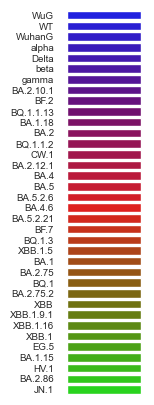

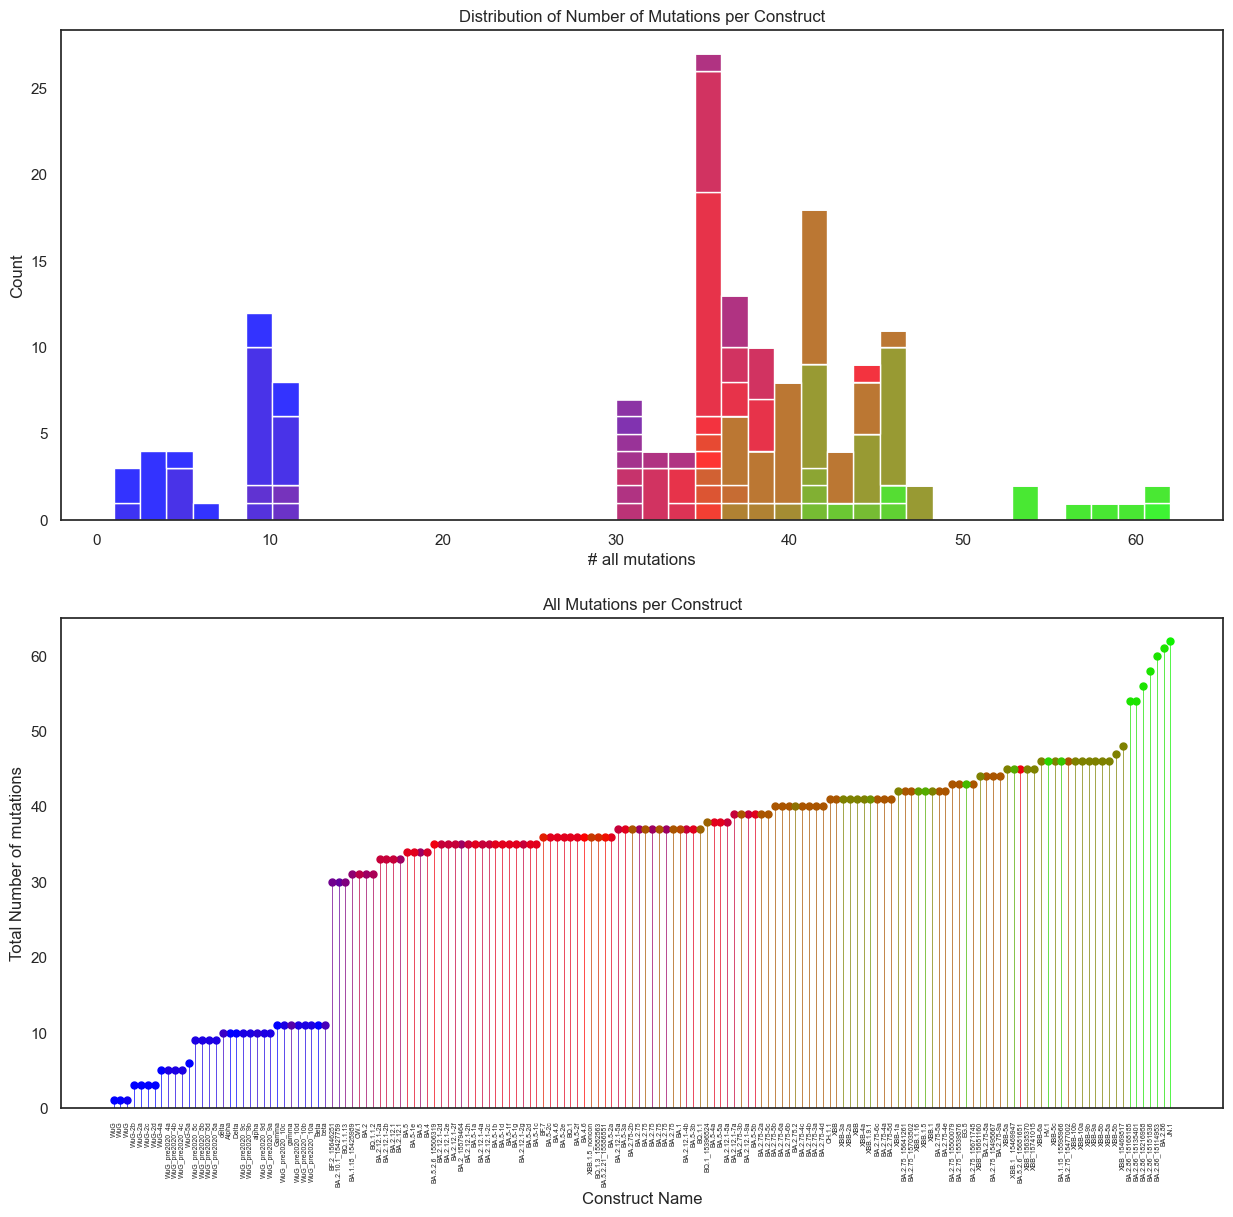

In [21]:
def get_cmap(df):
    cmap = plt.cm.get_cmap('brg')
    color_map = {}
    num_values = len(df['Base VoC'].unique())
    for i, voc in enumerate(df['Base VoC'].unique()):
        color_map[voc] = cmap(i / num_values)

    # Visualize Palette
    color_palette = sns.color_palette(color_map.values())
    plt.figure(figsize=(1, 5))
    sns.set(style="white")
    ax = sns.barplot(y=list(color_map.keys()), x=[1]*len(color_map), palette=color_palette)
    ax.set_yticklabels(list(color_map.keys()), fontsize=7)
    ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
    ax.set_xticks([])
    plt.show()
    
    return color_palette, color_map

all_seqs = create_all_seqs(inf_seqs, neu_seqs)
color_palette, color_map = get_cmap(all_seqs.sort_values(by=['# all mutations', 'Name']).reset_index(drop=True))

fig, axes = plt.subplots(2, 1, figsize=(15,14))
ax = axes[0]
sns.histplot(x='# all mutations',
             hue='Base VoC',
             multiple='stack',
             legend=False,
             palette=color_map,
             data=all_seqs,
             bins=40,
             edgecolor='white',
             alpha=0.8,
             ax=ax);
ax.set_title('Distribution of Number of Mutations per Construct');

ax = axes[1]
for voc, color in color_map.items():
    # color='xkcd:blue'
    ax.vlines(all_seqs[all_seqs['Base VoC']==voc].index, 0, all_seqs[all_seqs['Base VoC']==voc]['# all mutations'],
             color=color, linewidth=0.5)
    ax.plot(all_seqs[all_seqs['Base VoC']==voc].index, all_seqs[all_seqs['Base VoC']==voc]['# all mutations'], 
            color=color, marker='o', markersize=5, linestyle='')
    
ax.set_xticks(range(len(all_seqs)), labels=all_seqs['Name'], rotation=90, fontsize=5);
ax.set_ylim([0, max(all_seqs['# all mutations'])+3]);
ax.set_xlabel('Construct Name');
ax.set_ylabel('Total Number of mutations');
ax.set_title('All Mutations per Construct');

/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_50274/2127801036.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('brg')
/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_50274/2127801036.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=list(color_map.keys()), x=[1]*len(color_map), palette=color_palette)
/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_50274/2127801036.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(list(color_map.keys()), fontsize=7)


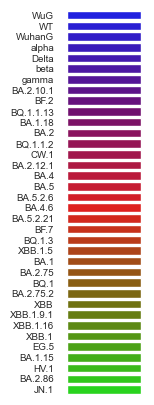

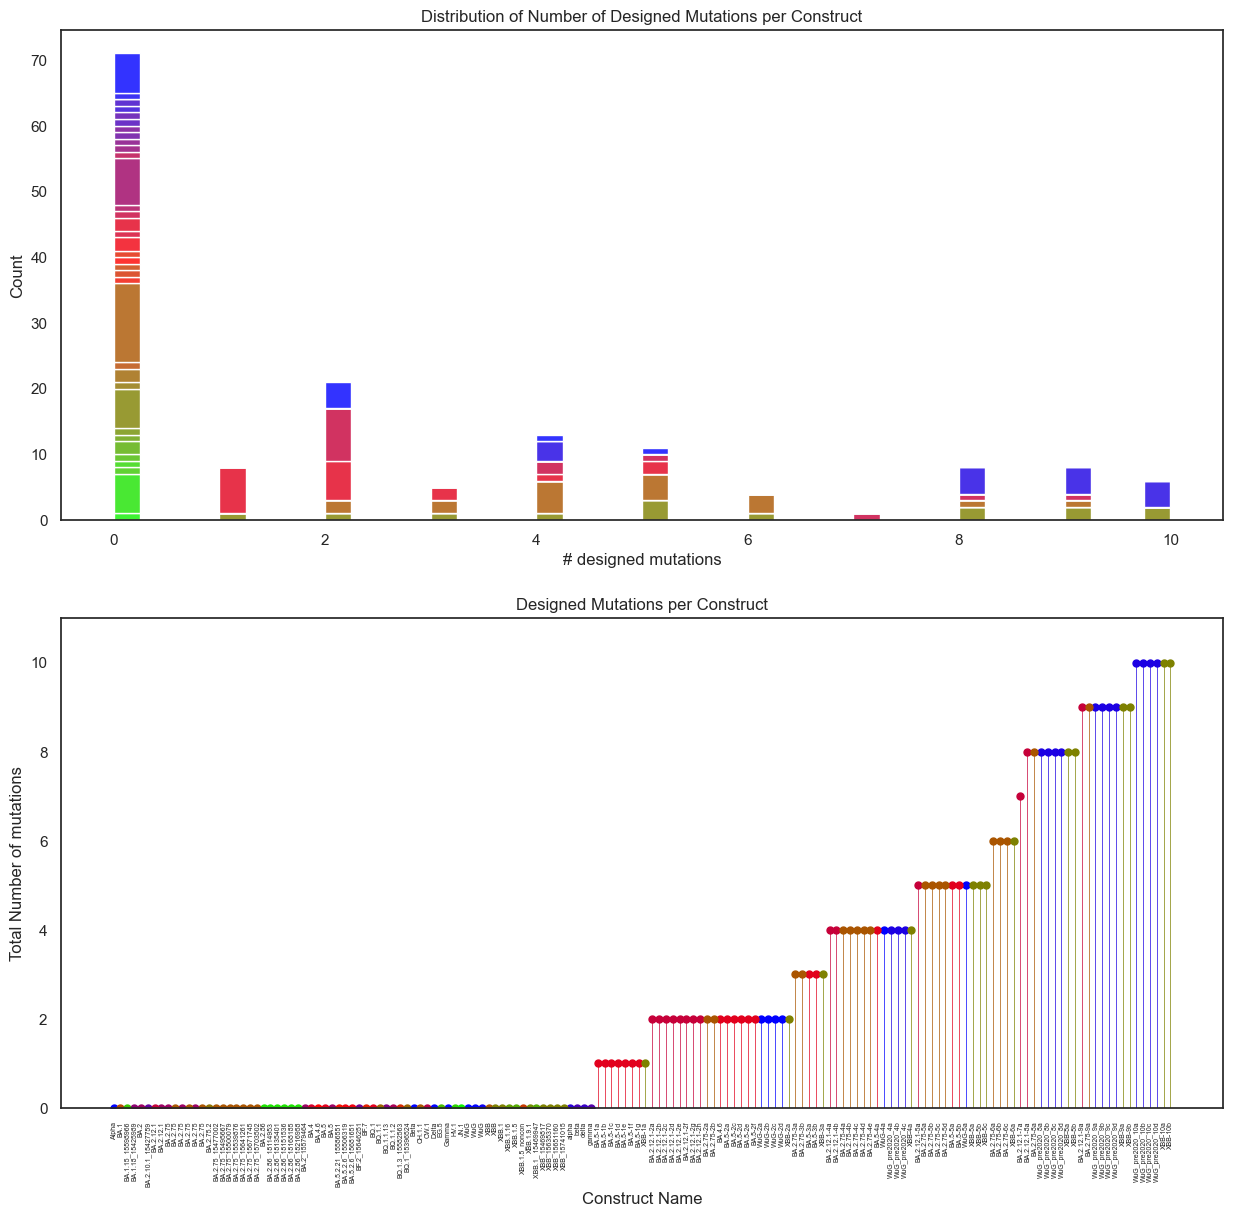

In [26]:
def get_cmap(df):
    cmap = plt.cm.get_cmap('brg')
    color_map = {}
    num_values = len(df['Base VoC'].unique())
    for i, voc in enumerate(df['Base VoC'].unique()):
        color_map[voc] = cmap(i / num_values)

    # Visualize Palette
    color_palette = sns.color_palette(color_map.values())
    plt.figure(figsize=(1, 5))
    sns.set(style="white")
    ax = sns.barplot(y=list(color_map.keys()), x=[1]*len(color_map), palette=color_palette)
    ax.set_yticklabels(list(color_map.keys()), fontsize=7)
    ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
    ax.set_xticks([])
    plt.show()
    
    return color_palette, color_map

all_seqs = create_all_seqs(inf_seqs, neu_seqs)
color_palette, color_map = get_cmap(all_seqs.sort_values(by=['# all mutations', 'Name']).reset_index(drop=True))

fig, axes = plt.subplots(2, 1, figsize=(15,14))
ax = axes[0]
sns.histplot(x='# designed mutations',
             hue='Base VoC',
             multiple='stack',
             legend=False,
             palette=color_map,
             data=all_seqs,
             bins=40,
             edgecolor='white',
             alpha=0.8,
             ax=ax);
ax.set_title('Distribution of Number of Designed Mutations per Construct');

ax = axes[1]
all_seqs = all_seqs.sort_values(by=['# designed mutations', 'Name']).reset_index(drop=True)
for voc, color in color_map.items():
    # color='xkcd:blue'
    ax.vlines(all_seqs[all_seqs['Base VoC']==voc].index, 0, all_seqs[all_seqs['Base VoC']==voc]['# designed mutations'],
             color=color, linewidth=0.5)
    ax.plot(all_seqs[all_seqs['Base VoC']==voc].index, all_seqs[all_seqs['Base VoC']==voc]['# designed mutations'], 
            color=color, marker='o', markersize=5, linestyle='')
    
ax.set_xticks(range(len(all_seqs)), labels=all_seqs['Name'], rotation=90, fontsize=5);
ax.set_ylim([0, max(all_seqs['# designed mutations'])+1]);
ax.set_xlabel('Construct Name');
ax.set_ylabel('Total Number of mutations');
ax.set_title('Designed Mutations per Construct');

### Serum pools

In [30]:
data_dir = '../data/Supp_Material/'
filename = 'Supp_TableS6_Neutralization_Data.csv'
neutralization = pd.read_csv(data_dir+filename)
neutralization = pd.melt(neutralization, id_vars='Name').rename(columns={'variable':'Pool', 'value':'Neutralization'})   # unpivot data
for p in neutralization['Pool'].unique():
    print(p)

Conv_Delta
Conv_WT-1
Conv_WT-2
Conv_WT-3
Vac_Mod-1
Vac_Mod-2
Vac_Pfiz-1
Vac_Pfiz-2
Vac_Pfiz-3
Boost_Mod-1
Boost_Mod-2
Boost_Mod-3
Boost_Pfiz-1
Boost_Pfiz-2
Bi-valent Boost
BTI_Delta-1
BTI_Delta-2
BTI_Delta-3
BTI_BA.1-1
BTI_BA.1-2
BTI_BA.1-3
BTI_BA.2.12.1
BTI_BA.4/5


### Aggregated Pools

In [31]:
neutralization['Pool'] = neutralization['Pool'].apply(lambda x: x if x=='Bi-valent Boost' else x.split('-')[0])
for p in neutralization['Pool'].unique():
    print(p)

Conv_Delta
Conv_WT
Vac_Mod
Vac_Pfiz
Boost_Mod
Boost_Pfiz
Bi-valent Boost
BTI_Delta
BTI_BA.1
BTI_BA.2.12.1
BTI_BA.4/5
